In [2]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv(r"C:\Users\pundr\Downloads\archive (1)\A_Z Handwritten Data.csv")
print(df.sample(5))
print(df.isnull().sum())

         0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.639  0.640  \
357755  24    0    0    0    0    0    0    0    0    0  ...      0      0   
73437    6    0    0    0    0    0    0    0    0    0  ...      0      0   
220906  16    0    0    0    0    0    0    0    0    0  ...      0      0   
336515  21    0    0    0    0    0    0    0    0    0  ...      0      0   
358452  24    0    0    0    0    0    0    0    0    0  ...      0      0   

        0.641  0.642  0.643  0.644  0.645  0.646  0.647  0.648  
357755      0      0      0      0      0      0      0      0  
73437       0      0      0      0      0      0      0      0  
220906      0      0      0      0      0      0      0      0  
336515      0      0      0      0      0      0      0      0  
358452      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]
0        0
0.1      0
0.2      0
0.3      0
0.4      0
        ..
0.644    0
0.645    0
0.646    0
0.647    0
0.648  

In [11]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: int64(785)
memory usage: 2.2 GB
None
(372450, 785)


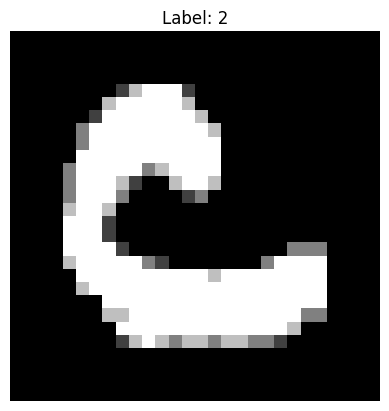

In [9]:
labels = df.iloc[:, 0]
pixels = df.iloc[:, 1:]
i = 40600	  # any index
img = pixels.iloc[i].values.reshape(28, 28)
plt.imshow(img, cmap='gray')
plt.title(f"Label: {labels.iloc[i]}")
plt.axis('off')
plt.show()



In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


features = df.iloc[:, 1:]
targets = df.iloc[:, 0]


useful_cols = features.columns[(features != 0).any(axis=0)]
features = features[useful_cols]


feats_train, feats_test, targs_train, targs_test = train_test_split(
    features, targets, test_size=0.2, random_state=42, stratify=targets
)


pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),      
    ("knn", KNeighborsClassifier(n_neighbors=5))   
])
pipeline.fit(feats_train, targs_train)


predictedknn = pipeline.predict(feats_test)


accuracyknn = accuracy_score(targs_test, predictedknn)
print("Accuracy:", accuracyknn)

# PCA final dimension
print("Reduced dimensions:", pipeline.named_steps["pca"].n_components_)


Accuracy: 0.9620083232648677
Reduced dimensions: 143
